# Package

In [33]:
library(tidyverse)
library(data.table)
library(showtext)
library(ragg)
library(psych)
library(car)
library(olsrr)
library(lmtest)

theme_set(theme_minimal())


##  글꼴 추가 및 셋팅
font_path <- "C:/Users/lgc/AppData/Local/Microsoft/Windows/Fonts/KoPub Dotum Light.ttf"
font_add(family = "kopub", regular = font_path)

## 이미지 저장 폰트 화질 및 크기 고정
showtext_opts(dpi = 200) 
showtext_auto()

## R 그래프 이미지 그릴 시 기본 셋팅
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200) 

# Data load

In [34]:
data <- fread('medical_insurance.csv')
glimpse(data)

Rows: 2,772
Columns: 7
$ age      <int> 19, 18, 28, 33, 32, 31, 46, 37, 37, 60, 25, 62, 23, 56, 27, 1…
$ sex      <chr> "female", "male", "male", "male", "male", "female", "female",…
$ bmi      <dbl> 27.900, 33.770, 33.000, 22.705, 28.880, 25.740, 33.440, 27.74…
$ children <int> 0, 1, 3, 0, 0, 0, 1, 3, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0…
$ smoker   <chr> "yes", "no", "no", "no", "no", "no", "no", "no", "no", "no", …
$ region   <chr> "southwest", "southeast", "southeast", "northwest", "northwes…
$ charges  <dbl> 16884.924, 1725.552, 4449.462, 21984.471, 3866.855, 3756.622,…


---

# Data processing

`1` 컬럼명 변경

In [35]:
data <- data %>% 
            rename(
                y = charges,
                x1 = age,
                x2 = sex,
                x3 = bmi,
                x4 = children,
                x5 = smoker,
                x6 = region
            )

`2` 문자형 변수 factor 처리

In [36]:
data <- data %>% 
            mutate_if(is.character, as.factor)

---

# EDA

## 반응변수(의료비) 분포 확인

`1` Y 분포

In [37]:
fig1 <- data %>% 
        ggplot(aes(x = y)) +
            geom_histogram(bins = 40, color = 'darkblue', fill = 'steelblue', alpha = 0.8) +
            labs(
                title = 'Histogram of Charge(Y) ',
                y = '빈도',
                x = '단위: 달러($)'
            ) +
        theme(
            text = element_text(family = 'kopub'),
            plot.title = element_text(size = 24, face = 'bold', hjust = 0.5),
            axis.title = element_text(size = 16),
            axis.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 14),
            axis.title.y = element_blank()
        )

ggsave(filename = "Figure/01. 반응변수 분포1.png",
        plot = fig1,
        units = "mm",
        dpi = 200,
        width = 170,
        height = 170)

## 상관분석

In [38]:
png(filename = "Figure/02. 상관분석.png", width = 800, height = 800, res = 200)
pairs.panels(x = data %>% 
                    select_if(is.numeric))

dev.off()

agg_record_26ac1bd32e45 
                      2

---

# Modeling

`1` 기본적인 다중 선형 회귀모델 적합

In [39]:
m1 <- lm(y~., data)

In [40]:
summary(m1)


Call:
lm(formula = y ~ ., data = data)

Residuals:
   Min     1Q Median     3Q    Max 
-11489  -2789  -1016   1340  29867 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -11635.451    686.885 -16.939  < 2e-16 ***
x1             255.577      8.268  30.913  < 2e-16 ***
x2male         -56.944    231.866  -0.246  0.80602    
x3             330.015     19.869  16.609  < 2e-16 ***
x4             506.343     95.164   5.321 1.12e-07 ***
x5yes        23976.197    288.461  83.118  < 2e-16 ***
x6northwest   -331.841    334.380  -0.992  0.32109    
x6southeast  -1078.362    334.418  -3.225  0.00128 ** 
x6southwest  -1055.254    333.121  -3.168  0.00155 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6073 on 2763 degrees of freedom
Multiple R-squared:  0.7509,	Adjusted R-squared:  0.7502 
F-statistic:  1041 on 8 and 2763 DF,  p-value: < 2.2e-16


In [41]:
vif(m1)

,GVIF,Df,GVIF^(1/(2*Df))
x1,1.018201,1,1.009060
x2,1.009875,1,1.004925
x3,1.114274,1,1.055592
x4,1.004017,1,1.002006
x5,1.013467,1,1.006711
x6,1.107600,3,1.017178


# Model tuning

## 연령변수 다항회귀 추가(2차항)

In [42]:
data2 <- tibble(data)
data2$x1_2 <- data2$x1^2

## BMI 수치변수 지시변수 추가

In [43]:
data2$x3_30 <- as.factor(ifelse(data2$x3 >= 30, 1, 0))

## 모델 적합

`-` BMI와 흡연의 상호작용까지 추가하여 모델 적합

In [44]:
m2 <- lm(y ~ x1_2 + x2 +  x3 + x3_30 + x4 + x5 + x6 + x3_30:x5 ,data2)

In [45]:
vif(m2)

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
x1_2,1.017697,1,1.008810
x2,1.012225,1,1.006094
x3,2.983432,1,1.727261
x3_30,3.025320,1,1.739345
x4,1.002771,1,1.001385
x5,2.170016,1,1.473098
x6,1.116905,3,1.018598
x3_30:x5,2.435140,1,1.560494


In [46]:
summary(m2)


Call:
lm(formula = y ~ x1_2 + x2 + x3 + x3_30 + x4 + x5 + x6 + x3_30:x5, 
    data = data2)

Residuals:
     Min       1Q   Median       3Q      Max 
-17383.8  -1664.7  -1276.0   -720.7  24268.1 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -2.230e+02  6.428e+02  -0.347 0.728705    
x1_2          3.311e+00  7.599e-02  43.577  < 2e-16 ***
x2male       -4.587e+02  1.708e+02  -2.686 0.007271 ** 
x3            1.148e+02  2.392e+01   4.799 1.68e-06 ***
x3_301       -9.750e+02  2.957e+02  -3.297 0.000989 ***
x4            6.612e+02  6.996e+01   9.451  < 2e-16 ***
x5yes         1.336e+04  3.105e+02  43.017  < 2e-16 ***
x6northwest  -2.278e+02  2.460e+02  -0.926 0.354630    
x6southeast  -9.254e+02  2.465e+02  -3.755 0.000177 ***
x6southwest  -1.315e+03  2.451e+02  -5.364 8.80e-08 ***
x3_301:x5yes  1.986e+04  4.238e+02  46.863  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4468 on 2761 degrees of

## 모형 성능 비교

In [47]:
r2_m1 <- summary(m1)$r.squared
r2_m2 <- summary(m2)$r.squared


cat("m1 결정계수:", r2_m1, "\n")
cat("m2 결정계수:", r2_m2, "\n")

m1 결정계수: 0.7509332 
m2 결정계수: 0.865326 


In [48]:
rmse_m1 <- sqrt(anova(m1)["Residuals", "Mean Sq"])
rmse_m2 <- sqrt(anova(m2)["Residuals", "Mean Sq"])

cat("m1 RMSE:", rmse_m1, "\n")
cat("m2 RMSE:", rmse_m2, "\n")

m1 RMSE: 6073.308 
m2 RMSE: 4467.519 


`1` cp값이 p+1이 되면 좋은 모형

In [49]:
cp_m1 <- ols_mallows_cp(m1, m2)
cp_m2 <- ols_mallows_cp(m2, m2)

cat("m1 CP값:", cp_m1, "\n")
cat("m2 CP값:", cp_m2, "\n")

m1 CP값: 2352.21 
m2 CP값: 11 


---

# 회귀진단

## 이상치 판단

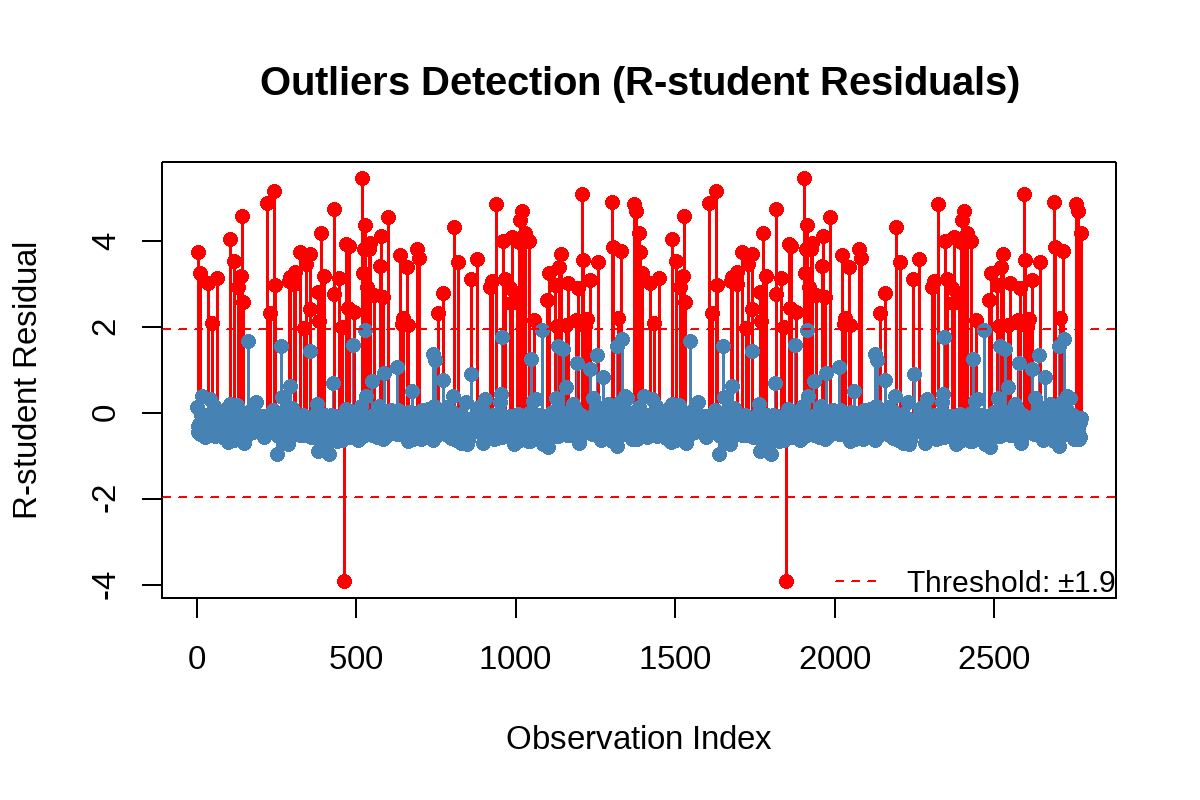

In [50]:
#png(filename = "Figure/03. 이상치 판난.png", width = 1000, height = 800, res = 200)
# 1. 통계량 계산 (m2 모형이 이미 존재한다고 가정)
n <- nobs(m2)
p_plus_1 <- length(coef(m2)) # 절편 포함 파라미터 수

# 외부 스튜던트화 잔차 (External Studentized Residuals) 계산
r_student <- rstudent(m2)

# t-분포 임계값 계산 (양측 검정, 95% 신뢰수준)
t_crit <- qt(0.975, df = n - p_plus_1 - 1)

# 2. 이상치 인덱스 자동 탐색
outlier_indices <- which(abs(r_student) >= t_crit)

# 3. 시각화
obs_index <- 1:n

# 전체 색상 배열 설정 (이상치는 빨간색, 나머지는 기본 파란색 계열)
pt_colors <- ifelse(abs(r_student) >= t_crit, "red", "steelblue")

# 그래프 여백(Y축)을 넉넉히 확보하여 라벨이 잘리지 않도록 설정
y_min <- min(r_student, -t_crit - 0.5)
y_max <- max(r_student, t_crit + 0.5)

plot(obs_index, r_student, type="h", col=pt_colors, lwd=1.5,
     main="Outliers Detection (R-student Residuals)",
     xlab="Observation Index", ylab="R-student Residual",
     ylim=c(y_min, y_max))

points(obs_index, r_student, pch=16, col=pt_colors)

# 임계선 추가
abline(h = t_crit, col="red", lty=2)
abline(h = -t_crit, col="red", lty=2)

# 이상치 인덱스 텍스트 라벨링 (Python의 fontweight='bold' -> R의 font=2)

# 범례(Legend) 추가
legend("bottomright", legend=sprintf("Threshold: ±%.2f", t_crit),
       col="red", lty=2, bty="n", cex=0.9)

# 결과 확인 (옵션)
#cat("계산된 t-임계값:", round(t_crit, 2), "\n")
#cat("탐지된 이상치 인덱스:", outlier_indices, "\n")

#dev.off()

In [51]:
# 결과 확인 (옵션)
cat("계산된 t-임계값:", round(t_crit, 2), "\n")
cat("탐지된 이상치 인덱스:", outlier_indices, "\n")

계산된 t-임계값: 1.96 
탐지된 이상치 인덱스: 4 10 35 46 63 103 116 129 139 141 144 220 228 243 246 290 292 306 307 322 335 341 355 356 380 383 388 398 430 431 444 456 462 469 474 477 492 517 521 525 527 534 540 544 555 574 578 584 600 638 642 645 659 662 689 697 755 771 807 820 859 877 918 926 937 960 965 981 984 988 1004 1009 1013 1020 1028 1040 1058 1099 1105 1124 1129 1135 1143 1158 1163 1190 1196 1207 1212 1216 1224 1231 1259 1301 1304 1319 1329 1370 1377 1385 1390 1396 1421 1432 1449 1489 1502 1515 1525 1527 1530 1606 1614 1629 1632 1676 1678 1692 1693 1708 1721 1727 1741 1742 1766 1769 1774 1784 1816 1817 1830 1842 1848 1855 1860 1863 1878 1903 1907 1911 1913 1920 1926 1930 1941 1960 1964 1970 1986 2024 2028 2031 2045 2048 2075 2083 2141 2157 2193 2206 2245 2263 2304 2312 2323 2346 2351 2367 2370 2374 2390 2395 2399 2406 2414 2426 2444 2485 2491 2510 2515 2521 2529 2544 2549 2576 2582 2593 2598 2602 2610 2617 2645 2687 2690 2705 2715 2756 2763 2771 


## 지룃대점

계산된 임계값 (h_crit): 0.008 
탐지된 지렛대점 인덱스: 287 439 544 848 861 1048 1086 1318 1673 1825 1930 2234 2247 2434 2472 2704 


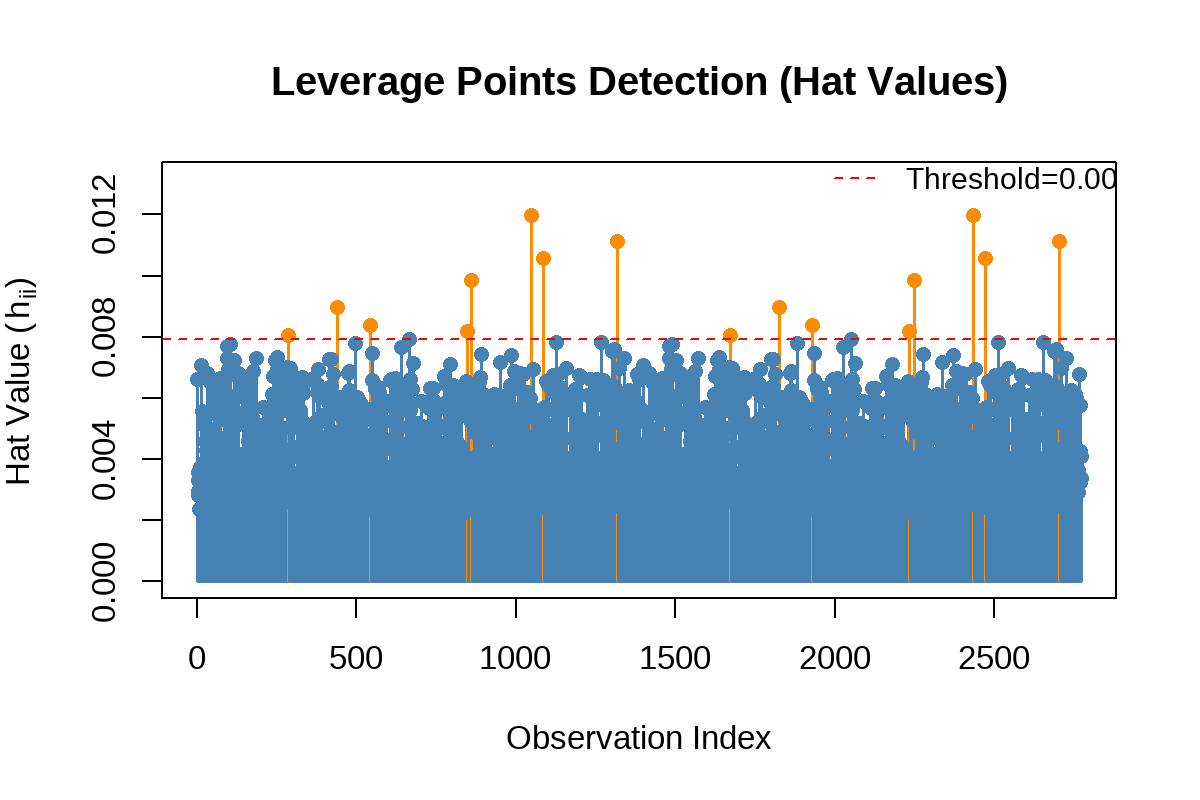

In [52]:
#png(filename = "Figure/04. 지룃대점 판단.png", width = 1000, height = 800, res = 200)
# 1. 계산 (m2 모형이 이미 존재한다고 가정)
n <- nobs(m2)
p_plus_1 <- length(coef(m2)) # 절편을 포함한 파라미터 수

# 햇 행렬의 대각 원소 (Hat values) 계산
hat_diag <- hatvalues(m2)

# 지렛대점 임계값 계산
h_crit <- 2 * p_plus_1 / n

# 2. 지렛대점 인덱스 자동 탐색
leverage_indices <- which(hat_diag > h_crit)

# 3. 시각화
obs_index <- 1:n

# 색상 배열 설정 (지렛대점은 주황색, 나머지는 파란색 계열)
pt_colors <- ifelse(hat_diag > h_crit, "darkorange", "steelblue")

# 텍스트 라벨이 잘리지 않도록 Y축 상단 여백을 10% 추가
y_max <- max(max(hat_diag), h_crit) * 1.1

# Python의 plt.stem() 효과를 내기 위한 type="h" (수직선) 그래프
plot(obs_index, hat_diag, type="h", col=pt_colors, lwd=1.5,
     main="Leverage Points Detection (Hat Values)",
     xlab="Observation Index", ylab=expression("Hat Value (" * h[ii] * ")"),
     ylim=c(0, y_max))

# 수직선 끝에 점 추가 (Python의 markerfmt="C1o")
points(obs_index, hat_diag, pch=16, col=pt_colors)

# 임계선 추가
abline(h = h_crit, col="red", lty=2)

# 범례(Legend) 추가
legend("topright", legend=sprintf("Threshold=%.3f", h_crit),
       col="red", lty=2, bty="n", cex=0.9)

# 결과 확인 (옵션)
cat("계산된 임계값 (h_crit):", round(h_crit, 3), "\n")
cat("탐지된 지렛대점 인덱스:", leverage_indices, "\n")
#dev.off()

## 영향점

계산된 F-분포 임계값 (d_crit): 0.94 
탐지된 영향점 인덱스:  


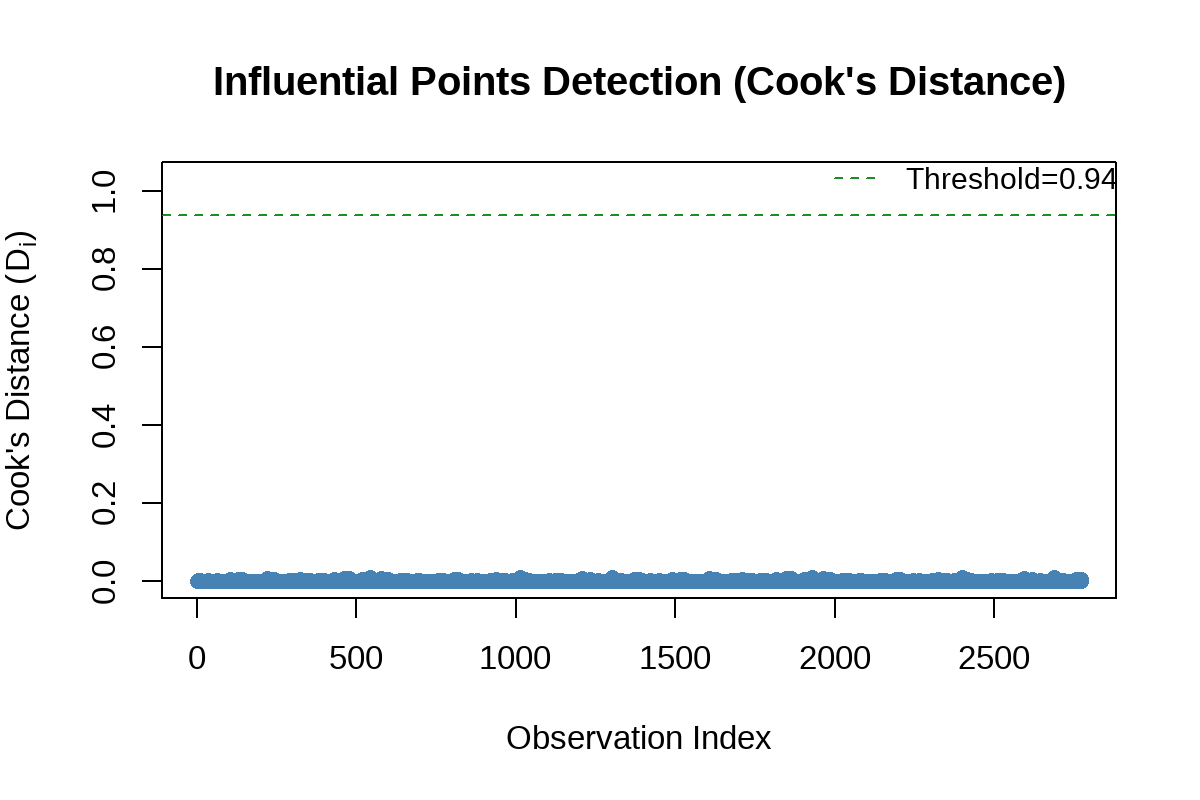

In [53]:
#png(filename = "Figure/05. 영향점 판단.png", width = 1000, height = 800, res = 200)
# 1. 계산 (m2 모형이 이미 존재한다고 가정)
n <- nobs(m2)
p_plus_1 <- length(coef(m2)) # 절편 포함 파라미터 수

# 쿡의 거리 (Cook's Distance) 계산
cooks_d <- cooks.distance(m2)

# F-분포 임계값 계산 (Python의 f.ppf(0.5, ...)와 동일)
d_crit <- qf(0.5, df1 = p_plus_1, df2 = n - p_plus_1)

# 2. 영향점 인덱스 자동 탐색
influential_indices <- which(cooks_d >= d_crit)

# 3. 시각화
obs_index <- 1:n

# 색상 배열 설정 (영향점은 녹색, 나머지는 파란색 계열)
pt_colors <- ifelse(cooks_d >= d_crit, "forestgreen", "steelblue")

# 텍스트 라벨이 잘리지 않도록 Y축 상단 여백을 10% 추가
y_max <- max(max(cooks_d), d_crit) * 1.1

# Python의 plt.stem() 효과 (수직선)
plot(obs_index, cooks_d, type="h", col=pt_colors, lwd=1.5,
     main="Influential Points Detection (Cook's Distance)",
     xlab="Observation Index", ylab=expression("Cook's Distance (" * D[i] * ")"),
     ylim=c(0, y_max))

# 수직선 끝에 점 추가
points(obs_index, cooks_d, pch=16, col=pt_colors)

# 임계선 추가
abline(h = d_crit, col="forestgreen", lty=2)

# 영향점 인덱스 텍스트 라벨링 (점의 위쪽(pos=3)에 굵게(font=2) 표시)
if(length(influential_indices) > 0) {
  text(influential_indices, cooks_d[influential_indices], 
       labels=influential_indices, pos=3, col="forestgreen", font=2, cex=0.9)
}

# 범례(Legend) 추가
legend("topright", legend=sprintf("Threshold=%.3f", d_crit),
       col="forestgreen", lty=2, bty="n", cex=0.9)

# 결과 확인 (옵션)
cat("계산된 F-분포 임계값 (d_crit):", round(d_crit, 3), "\n")
cat("탐지된 영향점 인덱스:", influential_indices, "\n")

#dev.off()

## 이상점, 지룃대점 제거 후 비교

In [54]:
# ========================================================
# [사전 작업] 이상점 및 지렛대점 인덱스 다시 계산
# ========================================================
# m2 모형의 관측치 수(n)와 파라미터 수(p)
n <- nobs(m2)
p <- length(coef(m2))

# 1. 이상점(Outlier) 인덱스 계산 (R-student 기준)
r_student <- rstudent(m2)
t_crit <- qt(0.975, df = n - p - 1)
outlier_idx <- which(abs(r_student) >= t_crit)

# 2. 지렛대점(Leverage) 인덱스 계산 (Hat value 기준)
hat_diag <- hatvalues(m2)
h_crit <- 2 * p / n
leverage_idx <- which(hat_diag > h_crit)

# ========================================================
# [메인 작업] 인덱스 통합 및 모형 비교 (m2 vs m3)
# ========================================================
# 1. 제거할 인덱스 통합 (중복 제거)
remove_idx <- unique(c(outlier_idx, leverage_idx))

cat("탐지된 이상점 인덱스:", outlier_idx, "\n")
cat("탐지된 지렛대점 인덱스:", leverage_idx, "\n")
cat("최종 제거 대상 데이터 인덱스 수:", length(remove_idx), "개\n\n")

# 2. m2 모형에 사용된 원본 데이터 추출 및 데이터 분리
data_orig <- m2$model
formula_m2 <- formula(m2)

if (length(remove_idx) > 0) {
  # 의심점들을 제외한 클린 데이터 생성
  data_clean <- data_orig[-remove_idx, ]
  
  # 3. 새로운 모형 m3 적합
  m3 <- lm(formula_m2, data=data_clean)
  
  # ========================================================
  # [분석 1] 모형 전체의 평가지표 및 유의성(F-통계량) 추출 함수
  # ========================================================
  get_model_stats <- function(model) {
    sm <- summary(model)
    n_obs <- nobs(model)
    rmse <- sqrt(mean(resid(model)^2))
    adj_r2 <- sm$adj.r.squared
    aic <- AIC(model)
    bic <- BIC(model)
    
    # F-통계량 및 모형의 p-value 계산
    fstat <- sm$fstatistic
    if (!is.null(fstat)) {
      f_val <- fstat[1]
      p_val <- pf(fstat[1], fstat[2], fstat[3], lower.tail = FALSE)
    } else {
      f_val <- NA
      p_val <- NA
    }
    
    return(c(n_obs, rmse, adj_r2, aic, bic, f_val, p_val))
  }
  
  stats_m2 <- get_model_stats(m2)
  stats_m3 <- get_model_stats(m3)
  
  # 지표 비교 데이터프레임 생성
  comparison_metrics <- data.frame(
    Metric = c("Observations (n)", "RMSE", "Adj R-squared", "AIC", "BIC", "F-statistic", "P-value (Model)"),
    m2_Before = round(stats_m2, 4),
    m3_After = round(stats_m3, 4)
  )
  
  # ========================================================
  # [분석 2] 개별 회귀계수 및 유의성(t-통계량) 추출
  # ========================================================
  sm2_coef <- summary(m2)$coefficients
  sm3_coef <- summary(m3)$coefficients
  
  # 변수명 추출 (절편 포함)
  vars <- rownames(sm2_coef)
  
  # 계수 비교 데이터프레임 생성
  coef_compare <- data.frame(
    Variable = vars,
    # m2 (기존 모형) 통계량
    m2_Estimate = round(sm2_coef[, "Estimate"], 4),
    m2_t_val = round(sm2_coef[, "t value"], 4),
    m2_p_val = round(sm2_coef[, "Pr(>|t|)"], 4),
    
    # m3 (이상치 제거 모형) 통계량
    m3_Estimate = round(sm3_coef[, "Estimate"], 4),
    m3_t_val = round(sm3_coef[, "t value"], 4),
    m3_p_val = round(sm3_coef[, "Pr(>|t|)"], 4),
    
    # 계수 변화율(%) = (새로운계수 - 기존계수) / |기존계수| * 100
    Diff_Percent = round((sm3_coef[, "Estimate"] - sm2_coef[, "Estimate"]) / abs(sm2_coef[, "Estimate"]) * 100, 2)
  )
  rownames(coef_compare) <- NULL
  
  # ========================================================
  # 결과 출력
  # ========================================================
  cat("================ [ 1. 모형 평가지표 및 전체 유의성 비교 ] ================\n")
  print(comparison_metrics, row.names = FALSE)
  cat("\n")
  
  cat("================ [ 2. 개별 회귀계수 및 유의성 비교 ] ================\n")
  print(coef_compare, row.names = FALSE)
  
} else {
  cat("제거할 이상점이나 지렛대점이 존재하지 않아 m3 모형을 적합하지 않습니다.\n")
}

탐지된 이상점 인덱스: 4 10 35 46 63 103 116 129 139 141 144 220 228 243 246 290 292 306 307 322 335 341 355 356 380 383 388 398 430 431 444 456 462 469 474 477 492 517 521 525 527 534 540 544 555 574 578 584 600 638 642 645 659 662 689 697 755 771 807 820 859 877 918 926 937 960 965 981 984 988 1004 1009 1013 1020 1028 1040 1058 1099 1105 1124 1129 1135 1143 1158 1163 1190 1196 1207 1212 1216 1224 1231 1259 1301 1304 1319 1329 1370 1377 1385 1390 1396 1421 1432 1449 1489 1502 1515 1525 1527 1530 1606 1614 1629 1632 1676 1678 1692 1693 1708 1721 1727 1741 1742 1766 1769 1774 1784 1816 1817 1830 1842 1848 1855 1860 1863 1878 1903 1907 1911 1913 1920 1926 1930 1941 1960 1964 1970 1986 2024 2028 2031 2045 2048 2075 2083 2141 2157 2193 2206 2245 2263 2304 2312 2323 2346 2351 2367 2370 2374 2390 2395 2399 2406 2414 2426 2444 2485 2491 2510 2515 2521 2529 2544 2549 2576 2582 2593 2598 2602 2610 2617 2645 2687 2690 2705 2715 2756 2763 2771 
탐지된 지렛대점 인덱스: 287 439 544 848 861 1048 1086 1318 1673 1825 193

## 제거 전후 시각화 비교

### fitted vs True

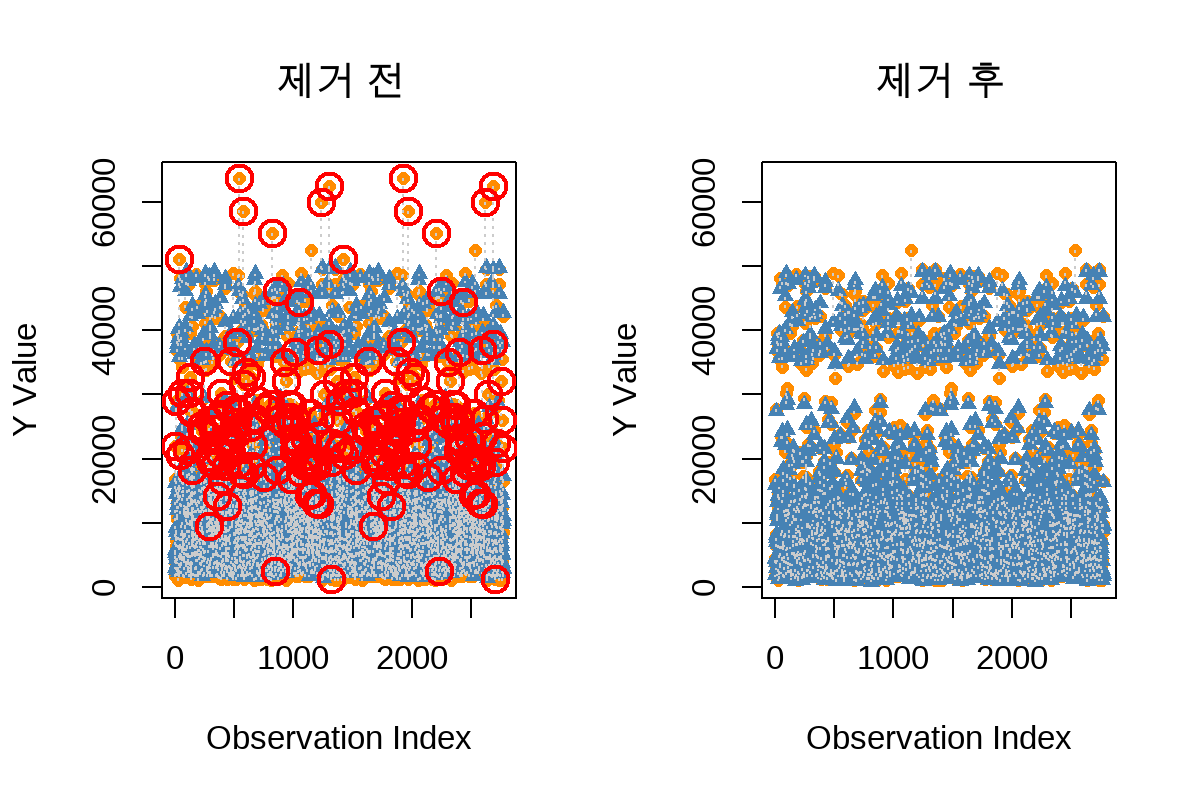

In [55]:
# 1. 화면 분할 (1행 2열) 및 하단 바깥쪽 여백(oma) 확보
# 하단에 범례가 들어갈 수 있도록 oma의 첫 번째 값(하단)을 4로 설정
#png(filename = "Figure/06. 특정점 제거 후 fitted vs ture 비교.png", width = 1800, height = 800, res = 200)
par(mfrow=c(1, 2))

# 2. 데이터 준비 (이전과 동일)
obs_full <- 1:nobs(m2)
y_full <- m2$model[, 1]   
fit_full <- fitted(m2)    

y_clean <- m3$model[, 1]  
fit_clean <- fitted(m3)   
obs_clean <- obs_full[-remove_idx] 

# 색상 및 점 모양 설정
col_actual <- "darkorange"
col_fit <- "steelblue"
pch_actual <- 16 
pch_fit <- 17    
y_range <- range(c(y_full, fit_full, y_clean, fit_clean))

# =========================================================
# [Plot 1] 이상치 제거 전 (m2 모형)
# =========================================================
plot(obs_full, y_full, pch=pch_actual, col=col_actual, cex=0.9,
     ylim=y_range, main="제거 전", 
     xlab="Observation Index", ylab="Y Value")
points(obs_full, fit_full, pch=pch_fit, col=col_fit, cex=0.9)
segments(obs_full, y_full, obs_full, fit_full, col="gray80", lty=3)

# 제거 대상 하이라이트
if(length(remove_idx) > 0) {
  points(remove_idx, y_full[remove_idx], pch=1, col="red", cex=1.8, lwd=2)
  #text(remove_idx, y_full[remove_idx], labels=remove_idx, pos=3, col="red", font=2, cex=0.8)
}

# =========================================================
# [Plot 2] 이상치 제거 후 (m3 모형)
# =========================================================
plot(obs_clean, y_clean, pch=pch_actual, col=col_actual, cex=0.9,
     ylim=y_range, main="제거 후", 
     xlab="Observation Index", ylab="Y Value")
points(obs_clean, fit_clean, pch=pch_fit, col=col_fit, cex=0.9)
segments(obs_clean, y_clean, obs_clean, fit_clean, col="gray80", lty=3)

# =========================================================
# [공통 범례 추가 - 그래프 외부 하단]
# =========================================================
# 전체 화면 기준(fig=c(0,1,0,1))으로 겹쳐 그리기(new=TRUE) 설정
par(fig=c(0, 1, 0, 1), oma=c(0, 0, 0, 0), mar=c(0, 0, 0, 0), new=TRUE)

# 투명한 빈 그래프 생성
plot(0, 0, type="n", bty="n", xaxt="n", yaxt="n", xlab="", ylab="")

# 설정 초기화
par(mfrow=c(1, 1), oma=c(0, 0, 0, 0), mar=c(5, 4, 4, 2) + 0.1)
#dev.off()

### 잔차 plot

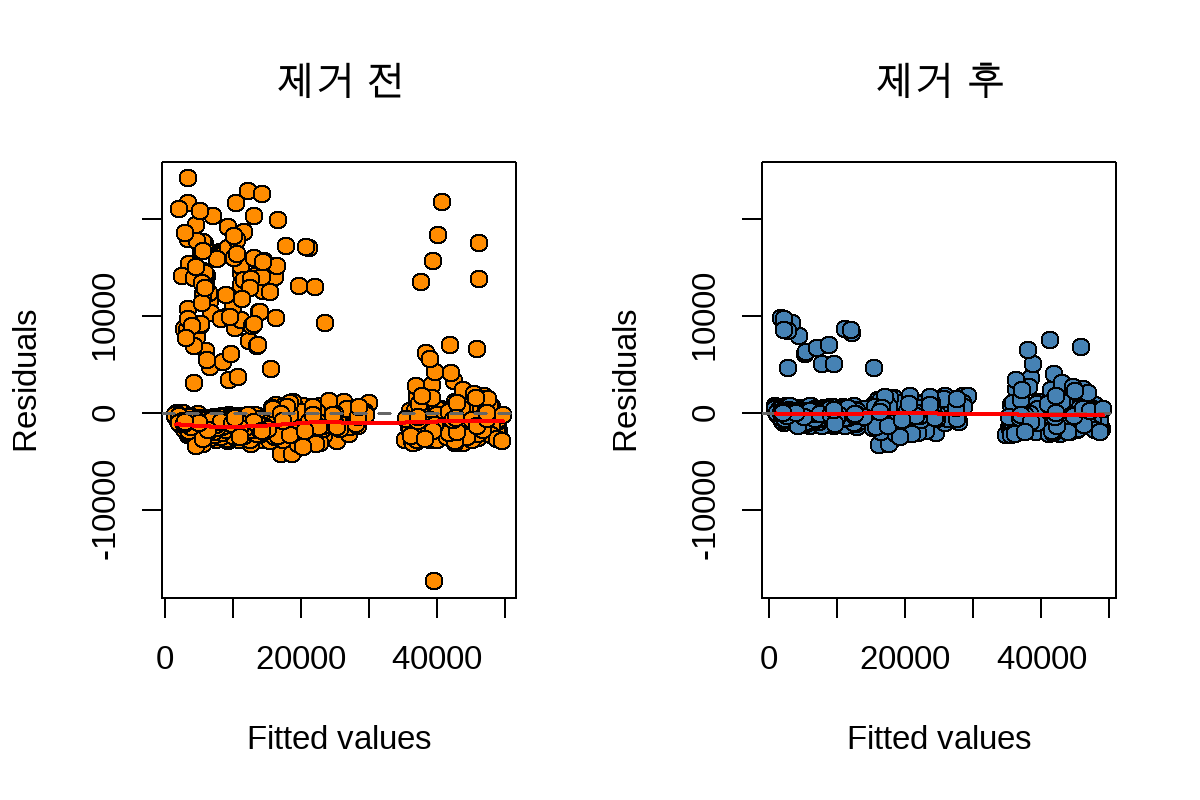

In [56]:
# 1. 두 모형의 잔차를 모아 동일한 Y축 범위(최소~최대) 계산
#png(filename = "Figure/07. 잔차plot 비교.png", width = 1800, height = 800, res = 200)
y_range <- range(c(resid(m2), resid(m3)))

# 2. 화면 분할 (1행 2열)
par(mfrow=c(1, 2))

# =========================================================
# [Plot 1] 제거 전 (m2) - 잔차 vs 적합값
# =========================================================
plot(fitted(m2), resid(m2), 
     ylim=y_range, 
     pch=21, bg="darkorange", col="black", cex=1.2, # 점 모양 예쁘게
     xlab="Fitted values", ylab="Residuals", 
     main="제거 전")

# 잔차의 기준점인 0을 지나는 가로 점선 추가
abline(h=0, col="gray40", lty=2, lwd=1.5)

# (선택) R 기본 plot(m2, 1)에 나오는 빨간색 추세선(평활선) 추가
lines(lowess(fitted(m2), resid(m2)), col="red", lwd=2)

# =========================================================
# [Plot 2] 제거 후 (m3) - 잔차 vs 적합값
# =========================================================
plot(fitted(m3), resid(m3), 
     ylim=y_range, 
     pch=21, bg="steelblue", col="black", cex=1.2,
     xlab="Fitted values", ylab="Residuals", 
     main="제거 후")

# 잔차의 기준점인 0 가로 점선 추가
abline(h=0, col="gray40", lty=2, lwd=1.5)

# (선택) 추세선(평활선) 추가
lines(lowess(fitted(m3), resid(m3)), col="red", lwd=2)

# 레이아웃 초기화
par(mfrow=c(1, 1))
#dev.off()

# 다시금 이상치, 지룃대점, 영향점 판단

## 이상치

계산된 t-임계값: 1.96 
탐지된 이상치 인덱스: 13 95 149 175 236 250 251 252 275 331 355 384 399 451 484 488 504 538 577 619 682 689 713 744 883 889 999 1017 1039 1046 1058 1068 1100 1134 1156 1174 1215 1228 1237 1292 1374 1428 1454 1515 1529 1530 1531 1554 1610 1634 1663 1678 1730 1763 1767 1783 1817 1856 1898 1961 1968 1992 2023 2162 2168 2278 2296 2318 2325 2337 2347 2379 2413 2435 2453 2494 2507 2516 


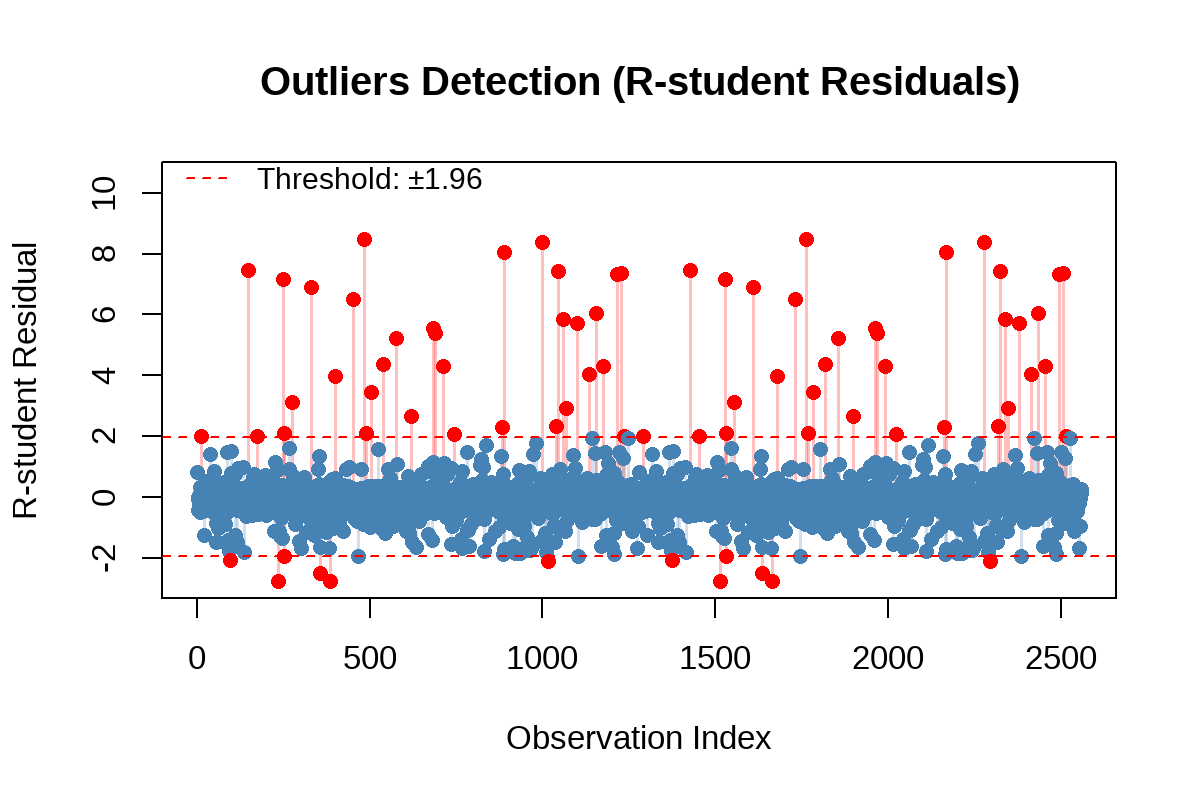

In [57]:
#png(filename = "Figure/08. 이상치 판단 (2).png", width = 1000, height = 800, res = 200)
# 1. 통계량 계산 (m2 모형이 이미 존재한다고 가정)
n <- nobs(m3)
p_plus_1 <- length(coef(m3)) # 절편 포함 파라미터 수

# 외부 스튜던트화 잔차 (External Studentized Residuals) 계산
r_student <- rstudent(m3)

# t-분포 임계값 계산 (양측 검정, 95% 신뢰수준)
t_crit <- qt(0.975, df = n - p_plus_1 - 1)

# 2. 이상치 인덱스 자동 탐색
outlier_indices <- which(abs(r_student) >= t_crit)

# 3. 시각화
obs_index <- 1:n

# 전체 색상 배열 설정 (이상치는 빨간색, 나머지는 기본 파란색 계열)
pt_colors <- ifelse(abs(r_student) >= t_crit, "red", "steelblue")

# 그래프 여백(Y축)을 넉넉히 확보하여 라벨이 잘리지 않도록 설정
y_min <- min(r_student, -t_crit - 0.5)
y_max <- max(r_student, t_crit + 0.5)

plot(obs_index, r_student, type="h", col=adjustcolor(pt_colors, 0.25), lwd=1.5,
     main="Outliers Detection (R-student Residuals)",
     xlab="Observation Index", ylab="R-student Residual",
     ylim=c(y_min, y_max+2))

points(obs_index, r_student, pch=16, col=pt_colors)

# 임계선 추가
abline(h = t_crit, col="red", lty=2)
abline(h = -t_crit, col="red", lty=2)

# 이상치 인덱스 텍스트 라벨링 (Python의 fontweight='bold' -> R의 font=2)

# 범례(Legend) 추가
legend("topleft", legend=sprintf("Threshold: ±%.2f", t_crit),
       col="red", lty=2, bty="n", cex=0.9)

# 결과 확인 (옵션)
cat("계산된 t-임계값:", round(t_crit, 2), "\n")
cat("탐지된 이상치 인덱스:", outlier_indices, "\n")

#dev.off()

## 지룃대점

계산된 임계값 (h_crit): 0.009 
탐지된 지렛대점 인덱스: 609 1039 1888 2318 


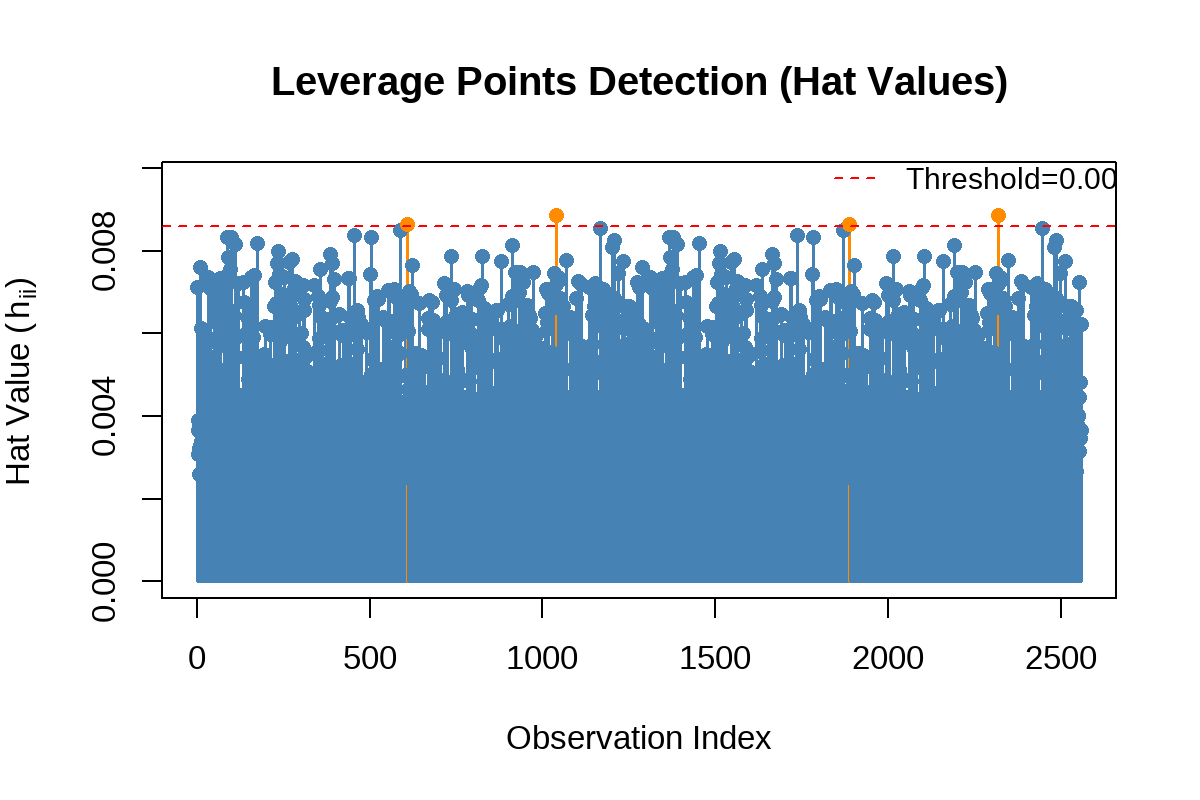

In [58]:
#png(filename = "Figure/09. 지룃대점 판단(2).png", width = 1000, height = 800, res = 200)
# 1. 계산 (m2 모형이 이미 존재한다고 가정)

# 햇 행렬의 대각 원소 (Hat values) 계산
hat_diag <- hatvalues(m3)

# 지렛대점 임계값 계산
h_crit <- 2 * p_plus_1 / n

# 2. 지렛대점 인덱스 자동 탐색
leverage_indices <- which(hat_diag > h_crit)

# 3. 시각화
obs_index <- 1:n

# 색상 배열 설정 (지렛대점은 주황색, 나머지는 파란색 계열)
pt_colors <- ifelse(hat_diag > h_crit, "darkorange", "steelblue")

# 텍스트 라벨이 잘리지 않도록 Y축 상단 여백을 10% 추가
y_max <- max(max(hat_diag), h_crit) * 1.1

# Python의 plt.stem() 효과를 내기 위한 type="h" (수직선) 그래프
plot(obs_index, hat_diag, type="h", col=pt_colors, lwd=1.5,
     main="Leverage Points Detection (Hat Values)",
     xlab="Observation Index", ylab=expression("Hat Value (" * h[ii] * ")"),
     ylim=c(0, y_max))

# 수직선 끝에 점 추가 (Python의 markerfmt="C1o")
points(obs_index, hat_diag, pch=16, col=pt_colors)

# 임계선 추가
abline(h = h_crit, col="red", lty=2)

# 범례(Legend) 추가
legend("topright", legend=sprintf("Threshold=%.3f", h_crit),
       col="red", lty=2, bty="n", cex=0.9)

# 결과 확인 (옵션)
cat("계산된 임계값 (h_crit):", round(h_crit, 3), "\n")
cat("탐지된 지렛대점 인덱스:", leverage_indices, "\n")
#dev.off()

## 영향점

계산된 F-분포 임계값 (d_crit): 0.94 
탐지된 영향점 인덱스:  


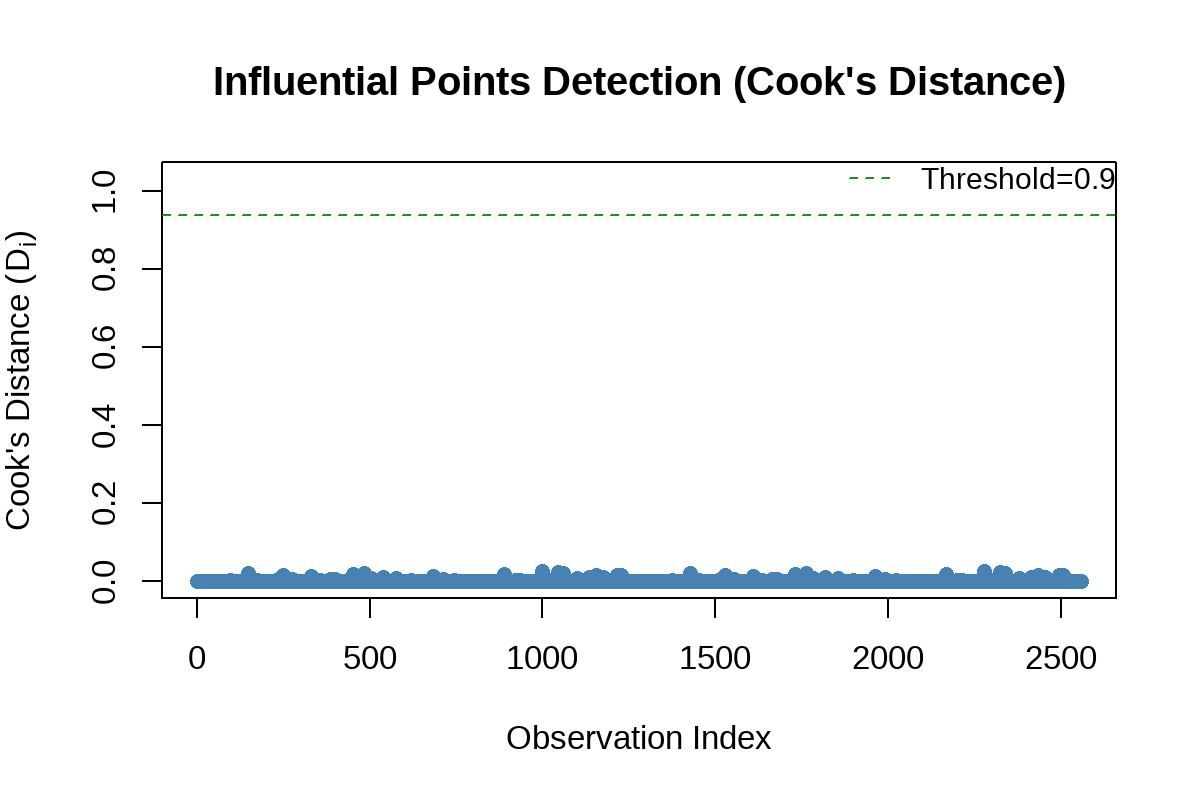

In [59]:
#png(filename = "Figure/10. 영향점 판단(2).png", width = 1000, height = 800, res = 200)
# 1. 계산 (m2 모형이 이미 존재한다고 가정)

# 쿡의 거리 (Cook's Distance) 계산
cooks_d <- cooks.distance(m3)

# F-분포 임계값 계산 (Python의 f.ppf(0.5, ...)와 동일)
d_crit <- qf(0.5, df1 = p_plus_1, df2 = n - p_plus_1)

# 2. 영향점 인덱스 자동 탐색
influential_indices <- which(cooks_d >= d_crit)

# 3. 시각화
obs_index <- 1:n

# 색상 배열 설정 (영향점은 녹색, 나머지는 파란색 계열)
pt_colors <- ifelse(cooks_d >= d_crit, "forestgreen", "steelblue")

# 텍스트 라벨이 잘리지 않도록 Y축 상단 여백을 10% 추가
y_max <- max(max(cooks_d), d_crit) * 1.1

# Python의 plt.stem() 효과 (수직선)
plot(obs_index, cooks_d, type="h", col=pt_colors, lwd=1.5,
     main="Influential Points Detection (Cook's Distance)",
     xlab="Observation Index", ylab=expression("Cook's Distance (" * D[i] * ")"),
     ylim=c(0, y_max))

# 수직선 끝에 점 추가
points(obs_index, cooks_d, pch=16, col=pt_colors)

# 임계선 추가
abline(h = d_crit, col="forestgreen", lty=2)

# 영향점 인덱스 텍스트 라벨링 (점의 위쪽(pos=3)에 굵게(font=2) 표시)
if(length(influential_indices) > 0) {
  text(influential_indices, cooks_d[influential_indices], 
       labels=influential_indices, pos=3, col="forestgreen", font=2, cex=0.9)
}

# 범례(Legend) 추가
legend("topright", legend=sprintf("Threshold=%.2f", d_crit),
       col="forestgreen", lty=2, bty="n", cex=0.9)

# 결과 확인 (옵션)
cat("계산된 F-분포 임계값 (d_crit):", round(d_crit, 3), "\n")
cat("탐지된 영향점 인덱스:", influential_indices, "\n")

#dev.off()

## 한번더 해당 관측치 제거

### 비교

In [60]:
# ========================================================
# [사전 작업] m3 모형 기준 이상점 및 지렛대점 인덱스 다시 계산
# ========================================================
# m3 모형의 관측치 수(n)와 파라미터 수(p)
n <- nobs(m3)
p <- length(coef(m3))

# 1. 이상점(Outlier) 인덱스 계산 (R-student 기준)
r_student <- rstudent(m3)
t_crit <- qt(0.975, df = n - p - 1)
outlier_idx <- which(abs(r_student) >= t_crit)

# 2. 지렛대점(Leverage) 인덱스 계산 (Hat value 기준)
hat_diag <- hatvalues(m3)
h_crit <- 2 * p / n
leverage_idx <- which(hat_diag > h_crit)

# ========================================================
# [메인 작업] 인덱스 통합 및 모형 비교 (m3 vs m4)
# ========================================================
# 1. 제거할 인덱스 통합 (중복 제거)
remove_idx <- unique(c(outlier_idx, leverage_idx))

cat("탐지된 이상점 인덱스:", outlier_idx, "\n")
cat("탐지된 지렛대점 인덱스:", leverage_idx, "\n")
cat("최종 제거 대상 데이터 인덱스 수:", length(remove_idx), "개\n\n")

# 2. m3 모형에 사용된 원본 데이터 추출 및 데이터 분리
data_orig <- m3$model
formula_m3 <- formula(m3)

if (length(remove_idx) > 0) {
  # 의심점들을 제외한 클린 데이터 생성
  data_clean <- data_orig[-remove_idx, ]
  
  # 3. 새로운 모형 m4 적합
  m4 <- lm(formula_m3, data=data_clean)
  
  # ========================================================
  # [분석 1] 모형 전체의 평가지표 및 유의성(F-통계량) 추출 함수
  # ========================================================
  get_model_stats <- function(model) {
    sm <- summary(model)
    n_obs <- nobs(model)
    rmse <- sqrt(mean(resid(model)^2))
    adj_r2 <- sm$adj.r.squared
    aic <- AIC(model)
    bic <- BIC(model)
    
    # F-통계량 및 모형의 p-value 계산
    fstat <- sm$fstatistic
    if (!is.null(fstat)) {
      f_val <- fstat[1]
      p_val <- pf(fstat[1], fstat[2], fstat[3], lower.tail = FALSE)
    } else {
      f_val <- NA
      p_val <- NA
    }
    
    return(c(n_obs, rmse, adj_r2, aic, bic, f_val, p_val))
  }
  
  stats_m3 <- get_model_stats(m3)
  stats_m4 <- get_model_stats(m4)
  
  # 지표 비교 데이터프레임 생성
  comparison_metrics <- data.frame(
    Metric = c("Observations (n)", "RMSE", "Adj R-squared", "AIC", "BIC", "F-statistic", "P-value (Model)"),
    m3_Before = round(stats_m3, 4),
    m4_After = round(stats_m4, 4)
  )
  
  # ========================================================
  # [분석 2] 개별 회귀계수 및 유의성(t-통계량) 추출
  # ========================================================
  sm3_coef <- summary(m3)$coefficients
  sm4_coef <- summary(m4)$coefficients
  
  # 변수명 추출 (절편 포함)
  vars <- rownames(sm3_coef)
  
  # 계수 비교 데이터프레임 생성
  coef_compare <- data.frame(
    Variable = vars,
    
    # m3 (기존 모형) 통계량
    m3_Estimate = round(sm3_coef[, "Estimate"], 4),
    m3_t_val = round(sm3_coef[, "t value"], 4),
    m3_p_val = round(sm3_coef[, "Pr(>|t|)"], 4),
    
    # m4 (이상치 제거 모형) 통계량
    m4_Estimate = round(sm4_coef[, "Estimate"], 4),
    m4_t_val = round(sm4_coef[, "t value"], 4),
    m4_p_val = round(sm4_coef[, "Pr(>|t|)"], 4),
    
    # 계수 변화율(%) = (새로운계수 - 기존계수) / |기존계수| * 100
    Diff_Percent = round((sm4_coef[, "Estimate"] - sm3_coef[, "Estimate"]) / abs(sm3_coef[, "Estimate"]) * 100, 2)
  )
  rownames(coef_compare) <- NULL
  
  # ========================================================
  # 결과 출력
  # ========================================================
  cat("================ [ 1. 모형 평가지표 및 전체 유의성 비교 ] ================\n")
  print(comparison_metrics, row.names = FALSE)
  cat("\n")
  
  cat("================ [ 2. 개별 회귀계수 및 유의성 비교 ] ================\n")
  print(coef_compare, row.names = FALSE)
  
} else {
  cat("제거할 이상점이나 지렛대점이 존재하지 않아 m4 모형을 적합하지 않습니다.\n")
}

탐지된 이상점 인덱스: 13 95 149 175 236 250 251 252 275 331 355 384 399 451 484 488 504 538 577 619 682 689 713 744 883 889 999 1017 1039 1046 1058 1068 1100 1134 1156 1174 1215 1228 1237 1292 1374 1428 1454 1515 1529 1530 1531 1554 1610 1634 1663 1678 1730 1763 1767 1783 1817 1856 1898 1961 1968 1992 2023 2162 2168 2278 2296 2318 2325 2337 2347 2379 2413 2435 2453 2494 2507 2516 
탐지된 지렛대점 인덱스: 609 1039 1888 2318 
최종 제거 대상 데이터 인덱스 수: 80 개

================ [ 1. 모형 평가지표 및 전체 유의성 비교 ] ================
           Metric  m3_Before   m4_After
 Observations (n)  2558.0000  2478.0000
             RMSE  1171.7783   566.1213
    Adj R-squared     0.9898     0.9974
              AIC 43434.3665 38471.3937
              BIC 43504.5303 38541.1762
      F-statistic 24910.8618 96613.4082
  P-value (Model)     0.0000     0.0000

================ [ 2. 개별 회귀계수 및 유의성 비교 ] ================
     Variable m3_Estimate m3_t_val m3_p_val m4_Estimate m4_t_val m4_p_val
  (Intercept)  -1318.8608  -7.3199   0.0000   -621.

## 제거 전후 시각화 비교(2)

### fitted vs True

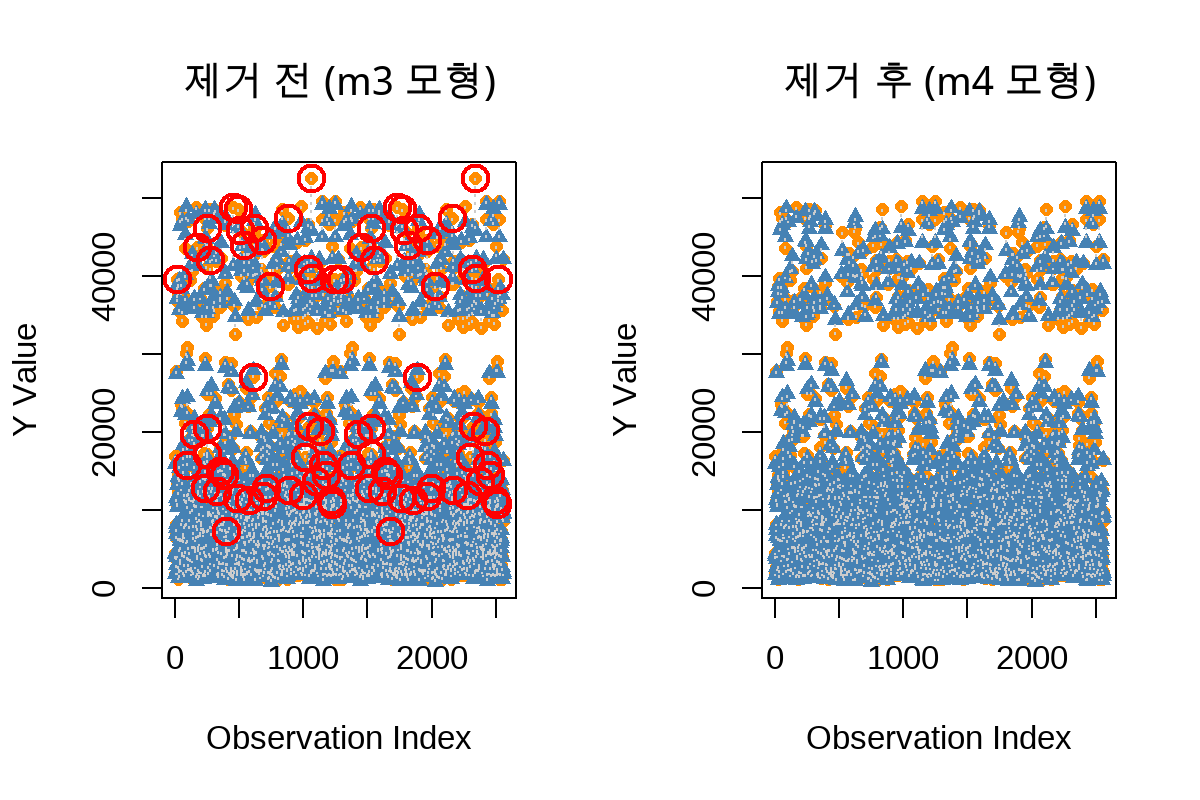

In [61]:
# (선택) 이미지로 저장하려면 아래 주석(#)을 해제하세요.
#png(filename = "Figure/11. 특정점 제거 후 fitted vs ture 비교(2).png", width = 1800, height = 800, res = 200)

# 1. 화면 분할 (1행 2열) 및 하단 바깥쪽 여백(oma) 확보
# 하단에 범례가 들어갈 수 있도록 oma의 첫 번째 값(하단)을 4로 설정
par(mfrow=c(1, 2))

# 2. 데이터 준비 (m3: 제거 전, m4: 제거 후)
obs_full <- 1:nobs(m3)
y_full <- m3$model[, 1]   
fit_full <- fitted(m3)    

y_clean <- m4$model[, 1]  
fit_clean <- fitted(m4)   
obs_clean <- obs_full[-remove_idx] 

# 색상 및 점 모양 설정
col_actual <- "darkorange"
col_fit <- "steelblue"
pch_actual <- 16 
pch_fit <- 17    
y_range <- range(c(y_full, fit_full, y_clean, fit_clean))

# =========================================================
# [Plot 1] 이상치 제거 전 (m3 모형)
# =========================================================
plot(obs_full, y_full, pch=pch_actual, col=col_actual, cex=0.9,
     ylim=y_range, main="제거 전 (m3 모형)", 
     xlab="Observation Index", ylab="Y Value")
points(obs_full, fit_full, pch=pch_fit, col=col_fit, cex=0.9)
segments(obs_full, y_full, obs_full, fit_full, col="gray80", lty=3)

# 제거 대상 하이라이트
if(length(remove_idx) > 0) {
  points(remove_idx, y_full[remove_idx], pch=1, col="red", cex=1.8, lwd=2)
  #text(remove_idx, y_full[remove_idx], labels=remove_idx, pos=3, col="red", font=2, cex=0.8)
}

# =========================================================
# [Plot 2] 이상치 제거 후 (m4 모형)
# =========================================================
plot(obs_clean, y_clean, pch=pch_actual, col=col_actual, cex=0.9,
     ylim=y_range, main="제거 후 (m4 모형)", 
     xlab="Observation Index", ylab="Y Value")
points(obs_clean, fit_clean, pch=pch_fit, col=col_fit, cex=0.9)
segments(obs_clean, y_clean, obs_clean, fit_clean, col="gray80", lty=3)

# =========================================================
# [공통 범례 추가 - 그래프 외부 하단]
# =========================================================
# 전체 화면 기준(fig=c(0,1,0,1))으로 겹쳐 그리기(new=TRUE) 설정
par(fig=c(0, 1, 0, 1), oma=c(0, 0, 0, 0), mar=c(0, 0, 0, 0), new=TRUE)

# 투명한 빈 그래프 생성
plot(0, 0, type="n", bty="n", xaxt="n", yaxt="n", xlab="", ylab="")


# 설정 초기화
par(mfrow=c(1, 1), oma=c(0, 0, 0, 0), mar=c(5, 4, 4, 2) + 0.1)

# (선택) png() 함수를 사용하셨다면 아래 코드로 디바이스를 닫아주세요.
#dev.off()

### 잔차 plot

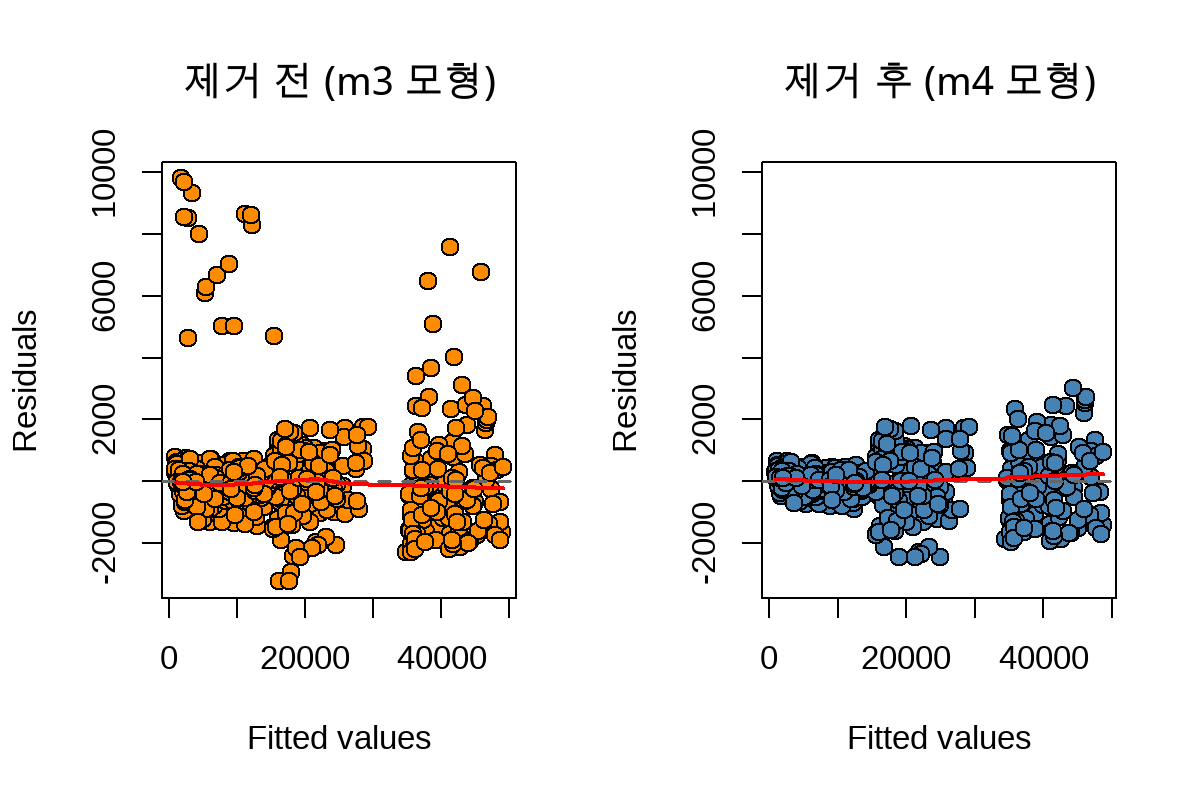

In [62]:
# 1. 두 모형의 잔차를 모아 동일한 Y축 범위(최소~최대) 계산
#png(filename = "Figure/12. 잔차plot 비교(2).png", width = 1800, height = 800, res = 200)
y_range <- range(c(resid(m3), resid(m4)))

# 2. 화면 분할 (1행 2열)
par(mfrow=c(1, 2))

# =========================================================
# [Plot 1] 제거 전 (m3) - 잔차 vs 적합값
# =========================================================
plot(fitted(m3), resid(m3), 
     ylim=y_range, 
     pch=21, bg="darkorange", col="black", cex=1.2, 
     xlab="Fitted values", ylab="Residuals", 
     main="제거 전 (m3 모형)")

abline(h=0, col="gray40", lty=2, lwd=1.5)

# ★ 수정됨: m3의 fitted와 m3의 resid만 사용
lines(lowess(fitted(m3), resid(m3)), col="red", lwd=2)

# =========================================================
# [Plot 2] 제거 후 (m4) - 잔차 vs 적합값
# =========================================================
plot(fitted(m4), resid(m4), 
     ylim=y_range, 
     pch=21, bg="steelblue", col="black", cex=1.2,
     xlab="Fitted values", ylab="Residuals", 
     main="제거 후 (m4 모형)")

abline(h=0, col="gray40", lty=2, lwd=1.5)

# ★ 수정됨: m4의 fitted와 m4의 resid만 사용
lines(lowess(fitted(m4), resid(m4)), col="red", lwd=2)

# 레이아웃 초기화
par(mfrow=c(1, 1))
#dev.off()

### qqplot

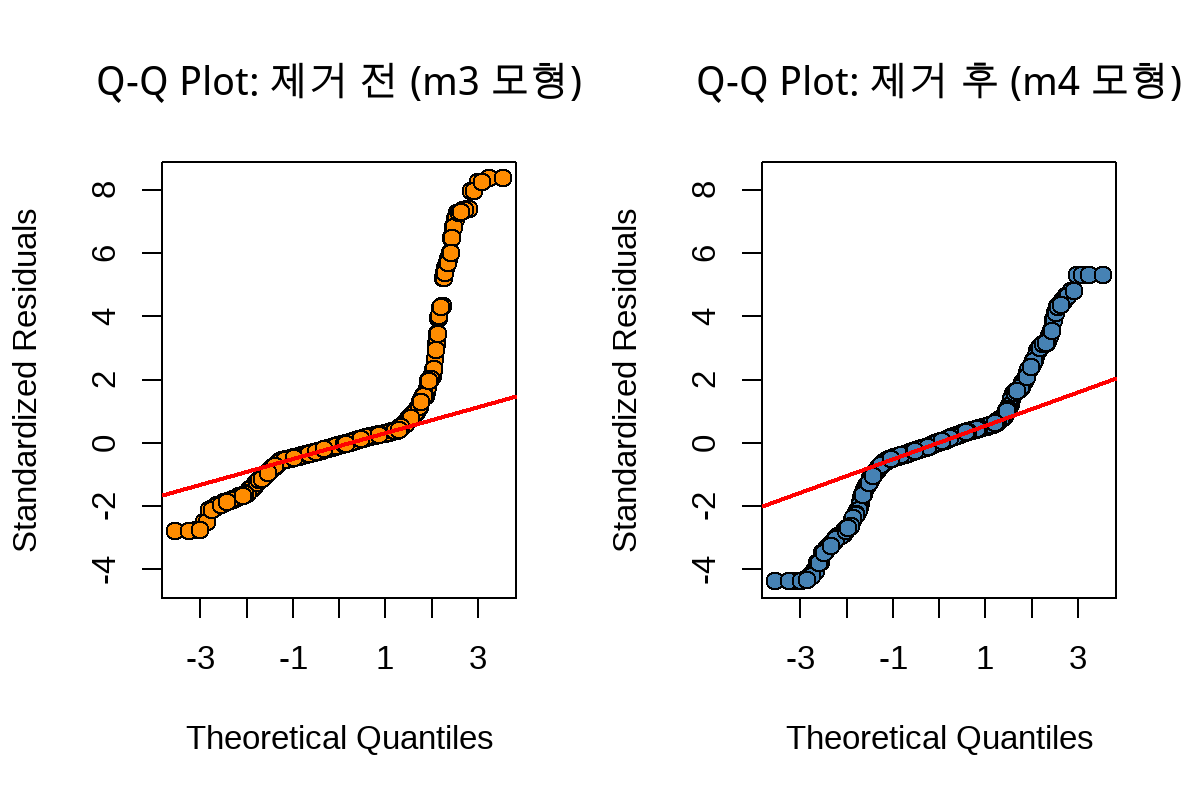

In [63]:
#png(filename = "Figure/13. QQplot 비교.png", width = 1800, height = 800, res = 200)

# 1. 두 모형의 표준화 잔차 추출 및 Q-Q 플롯용 좌표 사전 계산
std_res3 <- rstandard(m3)
std_res4 <- rstandard(m4)

qq_m3 <- qqnorm(std_res3, plot.it = FALSE)
qq_m4 <- qqnorm(std_res4, plot.it = FALSE)

# 두 그래프를 정확히 비교하기 위해 동일한 X, Y축 범위 계산
x_range <- range(c(qq_m3$x, qq_m4$x), na.rm = TRUE)
y_range <- range(c(qq_m3$y, qq_m4$y), na.rm = TRUE)

# 파일명 변경 (QQplot 비교)

# 2. 화면 분할 (1행 2열)
par(mfrow=c(1, 2))

# =========================================================
# [Plot 1] 제거 전 (m3) - Q-Q Plot
# =========================================================
plot(qq_m3$x, qq_m3$y, 
     xlim=x_range, ylim=y_range, 
     pch=21, bg="darkorange", col="black", cex=1.2, 
     xlab="Theoretical Quantiles", ylab="Standardized Residuals", 
     main="Q-Q Plot: 제거 전 (m3 모형)")

# 정규분포 기준선(대각선) 추가 (lowess 대신 qqline 사용)
qqline(std_res3, col="red", lwd=2)

# =========================================================
# [Plot 2] 제거 후 (m4) - Q-Q Plot
# =========================================================
plot(qq_m4$x, qq_m4$y, 
     xlim=x_range, ylim=y_range, 
     pch=21, bg="steelblue", col="black", cex=1.2,
     xlab="Theoretical Quantiles", ylab="Standardized Residuals", 
     main="Q-Q Plot: 제거 후 (m4 모형)")

# 정규분포 기준선(대각선) 추가
qqline(std_res4, col="red", lwd=2)

# 레이아웃 초기화
par(mfrow=c(1, 1))
#dev.off()

### dwtest

In [64]:
# 1. 패키지 설치 및 로드 (설치되어 있지 않다면 주석 해제)
# install.packages("lmtest")
library(lmtest)

# =========================================================
# 2. Durbin-Watson 검정 수행
# =========================================================

cat("================ [ 1. 제거 전 (m3 모형) ] ================\n")
# 기본값은 대립가설이 '양의 자기상관' (alternative="greater")입니다.
dw_m3 <- dwtest(m3)
print(dw_m3)

cat("\n================ [ 2. 제거 후 (m4 모형) ] ================\n")
dw_m4 <- dwtest(m4)
print(dw_m4)

# =========================================================
# 3. p-value를 통한 직관적 결론 출력 (유의수준 0.05 기준)
# =========================================================
cat("\n================ [ 최종 결론 해석 ] ================\n")

check_dw <- function(dw_result, model_name) {
  p_val <- dw_result$p.value
  d_stat <- dw_result$statistic
  
  cat(sprintf("[%s 모형] DW 통계량: %.3f, p-value: %.4f\n", model_name, d_stat, p_val))
  
  if(p_val > 0.05) {
    cat("  -> (결론) 귀무가설 채택: 잔차에 자기상관성이 존재하지 않습니다. (독립성 가정 만족)\n\n")
  } else {
    cat("  -> (결론) 귀무가설 기각: 잔차에 자기상관성이 존재합니다. (독립성 가정 위배)\n\n")
  }
}

check_dw(dw_m3, "m3")
check_dw(dw_m4, "m4")

================ [ 1. 제거 전 (m3 모형) ] ================

	Durbin-Watson test

data:  m3
DW = 2.0021, p-value = 0.5211
alternative hypothesis: true autocorrelation is greater than 0


================ [ 2. 제거 후 (m4 모형) ] ================

	Durbin-Watson test

data:  m4
DW = 2.0046, p-value = 0.5461
alternative hypothesis: true autocorrelation is greater than 0


================ [ 최종 결론 해석 ] ================
[m3 모형] DW 통계량: 2.002, p-value: 0.5211
  -> (결론) 귀무가설 채택: 잔차에 자기상관성이 존재하지 않습니다. (독립성 가정 만족)

[m4 모형] DW 통계량: 2.005, p-value: 0.5461
  -> (결론) 귀무가설 채택: 잔차에 자기상관성이 존재하지 않습니다. (독립성 가정 만족)

